In [ ]:
# DATA PROCESSING AND LOADING

In [1]:
from google.colab import files
uploaded = files.upload()

Saving banana_data.zip to banana_data.zip


In [31]:
# Assuming your zip is named 'banana_data.zip' (change if different)
zip_filename = 'banana_data.zip'  # Adjust to match your uploaded file's name

# Save the uploaded bytes to a file
with open(zip_filename, 'wb') as f:
    f.write(uploaded[zip_filename])

In [32]:
import zipfile
import os

# Define where to extract (change if needed)
extract_path = '/content/data_banana'

# Unzip
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Optional: List the extracted structure to verify
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files per folder
        print(f"{subindent}{file}")

data_banana/
  data_banana/
    train/
      labels/
        Raw_Banana.380207fd-7dd9-11ed-92e5-ca27fdb58ae8.txt
        Raw_Banana.b7ebaf01-7612-11ed-af77-d0ec6da7db5b.txt
        Ripe_Banana.83aaf9f5-7613-11ed-878e-d0ec6da7db5b.txt
        Raw_Banana.d6299823-7612-11ed-893c-d0ec6da7db5b.txt
        Ripe_Banana.5be88338-79f2-11ed-921b-c0b87d5d3464.txt
      images/
        Ripe_Banana.d34e8d03-7dda-11ed-b7d6-ca27fdb58ae8.jpg
        Ripe_Banana.12967c5b-7ddb-11ed-bf94-ca27fdb58ae8.jpg
        Raw_Banana.c458c63a-7dd9-11ed-b630-ca27fdb58ae8.jpg
        Ripe_Banana.1943fa3b-7613-11ed-b1cd-d0ec6da7db5b.jpg
        Ripe_Banana.9a7a0603-7dda-11ed-ae64-ca27fdb58ae8.jpg
    test/
      labels/
        Raw_Banana4_0_3455.txt
        Raw_Banana5_0_3082.txt
        Ripe_Banana.ede7a4de-7dda-11ed-b668-ca27fdb58ae8.txt
        Ripe_Banana1_0_9037.txt
        Ripe_Banana1_0_2921.txt
      images/
        Raw_Banana6_0_3452.jpg
        Ripe_Banana1_0_7705.jpg
        Raw_Banana3_0_2844.jpg
        

In [33]:
import os
import shutil
from collections import defaultdict
import random

def resplit_banana_data(source_dir="/content/data_banana/data_banana", output_dir="/content/data_banana_fixed",
                        train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Re-split banana dataset so each unique banana (e.g., Raw_Banana1, Raw_Banana2)
    appears in only ONE of train/val/test splits.

    Args:
        source_dir: Directory containing current train/val/test folders
        output_dir: Directory where properly split data will be saved
        train_ratio: Proportion for training set
        val_ratio: Proportion for validation set
        test_ratio: Proportion for test set
        seed: Random seed for reproducibility
    """
    random.seed(seed)

    print(f"Current working directory: {os.getcwd()}")
    print(f"Source directory: {source_dir}")
    print(f"Source exists: {os.path.exists(source_dir)}")

    # Create output directories
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)

    # Collect all images from all current splits
    all_images = []
    for split in ['train', 'val', 'test']:
        images_dir = os.path.join(source_dir, split, 'images')
        print(f"\nChecking directory: {images_dir}")
        print(f"  Exists: {os.path.exists(images_dir)}")
        if os.path.exists(images_dir):
            files = os.listdir(images_dir)
            print(f"  Files found: {len(files)}")
            for fname in files:
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                    all_images.append((split, fname))

    print(f"\nTotal images found: {len(all_images)}")

    if len(all_images) == 0:
        print("\n❌ ERROR: No images found!")
        print("Please check your directory structure.")
        print("\nTrying to list what's in /content:")
        if os.path.exists("/content"):
            print(os.listdir("/content"))
        return None

    # Group images by unique banana ID
    banana_groups = defaultdict(list)
    for split, fname in all_images:
        # Extract banana ID (e.g., "Raw_Banana1", "Ripe_Banana4")
        if "Raw_Banana" in fname:
            parts = fname.split("Raw_Banana")[1].split("_")[0]
            banana_id = "Raw_Banana" + ''.join(c for c in parts if c.isdigit() or c == '.')
            if not banana_id[-1].isdigit():
                banana_id = "Raw_Banana" + parts.split('.')[0]
        elif "Ripe_Banana" in fname:
            parts = fname.split("Ripe_Banana")[1].split("_")[0]
            banana_id = "Ripe_Banana" + ''.join(c for c in parts if c.isdigit() or c == '.')
            if not banana_id[-1].isdigit():
                banana_id = "Ripe_Banana" + parts.split('.')[0]
        else:
            continue

        banana_groups[banana_id].append((split, fname))

    print(f"\nFound {len(banana_groups)} unique bananas:")

    # Separate by class
    raw_bananas = sorted([bid for bid in banana_groups.keys() if "Raw" in bid])
    ripe_bananas = sorted([bid for bid in banana_groups.keys() if "Ripe" in bid])

    print(f"  Raw bananas: {len(raw_bananas)}")
    print(f"  Ripe bananas: {len(ripe_bananas)}")

    # Display counts per banana (show first 5 of each)
    print(f"\n  Sample Raw banana IDs: {raw_bananas[:5]}")
    print(f"  Sample Ripe banana IDs: {ripe_bananas[:5]}")

    # Shuffle banana IDs (not individual images)
    random.shuffle(raw_bananas)
    random.shuffle(ripe_bananas)

    # Split banana IDs into train/val/test
    def split_list(lst, ratios):
        n = len(lst)
        train_n = int(n * ratios[0])
        val_n = int(n * ratios[1])
        return lst[:train_n], lst[train_n:train_n+val_n], lst[train_n+val_n:]

    raw_train, raw_val, raw_test = split_list(raw_bananas, [train_ratio, val_ratio, test_ratio])
    ripe_train, ripe_val, ripe_test = split_list(ripe_bananas, [train_ratio, val_ratio, test_ratio])

    # Combine and assign to splits
    splits = {
        'train': raw_train + ripe_train,
        'val': raw_val + ripe_val,
        'test': raw_test + ripe_test
    }

    print("\n" + "="*60)
    print("NEW DATA SPLIT:")
    print("="*60)

    # Copy images to new splits
    for split_name, banana_ids in splits.items():
        image_count = 0
        raw_count = 0
        ripe_count = 0

        for banana_id in banana_ids:
            for old_split, fname in banana_groups[banana_id]:
                src = os.path.join(source_dir, old_split, 'images', fname)
                dst = os.path.join(output_dir, split_name, 'images', fname)
                shutil.copy2(src, dst)
                image_count += 1

                if "Raw" in fname:
                    raw_count += 1
                else:
                    ripe_count += 1

        print(f"\n{split_name.upper()} SET:")
        print(f"  Unique bananas: {len(banana_ids)}")
        print(f"  Total images: {image_count}")
        print(f"    Raw: {raw_count}")
        print(f"    Ripe: {ripe_count}")

    print("\n" + "="*60)
    print(f"✓ Data successfully re-split into: {output_dir}")
    print("="*60)

    return output_dir

# Run the re-splitting with COLAB paths
new_data_dir = resplit_banana_data(
    source_dir="/content/data_banana/data_banana",  # Adjust this to match YOUR unzipped path
    output_dir="/content/data_banana_fixed",
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42

    # different ratio of split
# new_data_dir = resplit_banana_data(
#     source_dir="/content/data_banana/data_banana",
#     output_dir="/content/data_banana_fixed",
#     train_ratio=0.60,
#     val_ratio=0.20,
#     test_ratio=0.20,
#     seed=42
#)
)

Current working directory: /content
Source directory: /content/data_banana/data_banana
Source exists: True

Checking directory: /content/data_banana/data_banana/train/images
  Exists: True
  Files found: 872

Checking directory: /content/data_banana/data_banana/val/images
  Exists: True
  Files found: 195

Checking directory: /content/data_banana/data_banana/test/images
  Exists: True
  Files found: 273

Total images found: 1340

Found 16 unique bananas:
  Raw bananas: 10
  Ripe bananas: 6

  Sample Raw banana IDs: ['Raw_Banana', 'Raw_Banana1', 'Raw_Banana2', 'Raw_Banana3', 'Raw_Banana4']
  Sample Ripe banana IDs: ['Ripe_Banana', 'Ripe_Banana1', 'Ripe_Banana4', 'Ripe_Banana5', 'Ripe_Banana6']

NEW DATA SPLIT:

TRAIN SET:
  Unique bananas: 11
  Total images: 861
    Raw: 187
    Ripe: 674

VAL SET:
  Unique bananas: 1
  Total images: 21
    Raw: 21
    Ripe: 0

TEST SET:
  Unique bananas: 4
  Total images: 458
    Raw: 396
    Ripe: 62

✓ Data successfully re-split into: /content/data_b

In [34]:
# Now load the FIXED data
train_loader, val_loader, test_loader = get_dataloaders(data_dir="/content/data_banana_fixed")

print(f"\nFixed dataset loaded:")
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Val dataset size: {len(val_loader.dataset)}")
print(f"Test dataset size: {len(test_loader.dataset)}")


Fixed dataset loaded:
Train dataset size: 861
Val dataset size: 21
Test dataset size: 458


In [30]:
# import os
# from PIL import Image
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms

# class BananaDataset(Dataset):
#     def __init__(self, images_dir, transform=None):
#         self.images_dir = images_dir
#         self.transform = transform
#         self.images = []

#         for fname in os.listdir(images_dir):
#             if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
#                 # determine class from filename
#                 if "Ripe_Banana" in fname:
#                     label = 1
#                 elif "Raw_Banana" in fname:
#                     label = 0
#                 else:
#                     continue
#                 self.images.append((os.path.join(images_dir, fname), label))

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img_path, label = self.images[idx]
#         image = Image.open(img_path).convert("RGB")
#         if self.transform:
#             image = self.transform(image)
#         return image, label

# def get_dataloaders(data_dir="data_banana", batch_size=32):
#     transform = transforms.Compose([
#         transforms.Resize((224,224)),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
#     ])

#     train_ds = BananaDataset(os.path.join(data_dir, "train/images"), transform=transform)
#     val_ds   = BananaDataset(os.path.join(data_dir, "val/images"), transform=transform)
#     test_ds  = BananaDataset(os.path.join(data_dir, "test/images"), transform=transform)

#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
#     val_loader   = DataLoader(val_ds, batch_size=batch_size)
#     test_loader  = DataLoader(test_ds, batch_size=batch_size)

#     return train_loader, val_loader, test_loader



In [23]:
# import os
# from PIL import Image
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torchvision import models
# import numpy as np
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# class BananaDataset(Dataset):
#     def __init__(self, images_dir, transform=None):
#         self.images_dir = images_dir
#         self.transform = transform
#         self.images = []

#         if not os.path.exists(images_dir):
#             raise ValueError(f"Directory {images_dir} does not exist. Check your unzipped data structure. Current cwd: {os.getcwd()}")

#         print(f"Loading images from: {images_dir}")  # Debug print
#         for fname in os.listdir(images_dir):
#             if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
#                 # Determine class from filename
#                 if "Ripe_Banana" in fname:
#                     label = 1
#                 elif "Raw_Banana" in fname:
#                     label = 0
#                 else:
#                     continue
#                 self.images.append((os.path.join(images_dir, fname), label))
#         print(f"Found {len(self.images)} images.")  # Debug print

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img_path, label = self.images[idx]
#         image = Image.open(img_path).convert("RGB")
#         if self.transform:
#             image = self.transform(image)
#         return image, label

# def get_dataloaders(data_dir="/content/data_banana/data_banana", batch_size=32):  # Updated default path
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])

#     # Adjust if your zip doesn't have 'images' subfolders (e.g., use "train" instead of "train/images")
#     train_images_dir = os.path.join(data_dir, "train/images")  # Change to "train" if no images/ subfolder
#     val_images_dir = os.path.join(data_dir, "val/images")
#     test_images_dir = os.path.join(data_dir, "test/images")

#     train_ds = BananaDataset(train_images_dir, transform=transform)
#     val_ds = BananaDataset(val_images_dir, transform=transform)
#     test_ds = BananaDataset(test_images_dir, transform=transform)

#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
#     val_loader = DataLoader(val_ds, batch_size=batch_size)
#     test_loader = DataLoader(test_ds, batch_size=batch_size)

#     return train_loader, val_loader, test_loader

In [24]:
# # Get the dataloaders (now with the correct path)
# train_loader, val_loader, test_loader = get_dataloaders()

# # Quick test
# print(f"Train dataset size: {len(train_loader.dataset)}")
# print(f"Val dataset size: {len(val_loader.dataset)}")
# print(f"Test dataset size: {len(test_loader.dataset)}")

Loading images from: /content/data_banana/data_banana/train/images
Found 872 images.
Loading images from: /content/data_banana/data_banana/val/images
Found 195 images.
Loading images from: /content/data_banana/data_banana/test/images
Found 273 images.
Train dataset size: 872
Val dataset size: 195
Test dataset size: 273


Label: 1 (0=Raw Banana, 1=Ripe Banana)


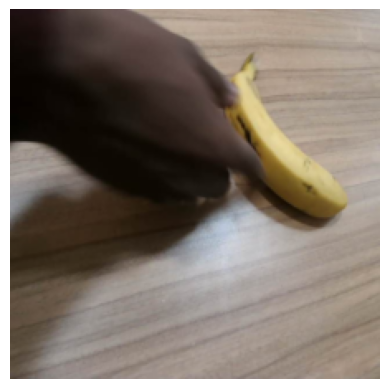

In [35]:
import matplotlib.pyplot as plt
import torch  # Assuming PyTorch is imported

# Grab one batch from the train loader
images, labels = next(iter(train_loader))

# Select the first image and label from the batch
image = images[0]  # Shape: [3, 224, 224]
label = labels[0].item()  # Convert tensor to int (0=Raw, 1=Ripe)

# Preprocess for display:
# 1. Permute to [H, W, C] (Matplotlib expects height, width, channels)
image = image.permute(1, 2, 0)  # Now [224, 224, 3]

# 2. Unnormalize (reverse the normalization applied in transforms)
# Using the same mean and std from your transforms
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
image = image * std + mean  # Unnormalize

# 3. Clip to [0, 1] range (in case of slight overflow) and convert to numpy
image = torch.clamp(image, 0, 1).numpy()

# Display
print(f"Label: {label} (0=Raw Banana, 1=Ripe Banana)")
plt.imshow(image)
plt.axis('off')  # Hide axes for cleaner look
plt.show()

In [36]:
if torch.cuda.is_available():
  print("GPU detected")
  device = torch.device("cuda")
else:
  print("No GPU detected")
  device = torch.device("cpu")

GPU detected


# FUNCTIONS

In [37]:
def get_accuracy_and_loss(model, loader, criterion):
  model.eval()
  my_loss = 0
  with torch.no_grad():
    correct = 0
    for data, target in loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      pred = output.argmax(dim=1)
      correct += pred.eq(target).sum().item()
      my_loss += criterion(output, target).item()
  return correct/len(loader.dataset), my_loss/len(loader.dataset)

In [38]:
def evaluate_model_metrics(model, test_loader, model_name="Model"):
    """
    Evaluate a model with detailed metrics including precision, recall, F1, and confusion matrix

    Args:
        model: The model to evaluate
        test_loader: DataLoader for test data
        model_name: Name to display in results
    """
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Get predictions on test set
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, support = precision_recall_fscore_support(all_targets, all_preds, average='binary')

    print("=" * 50)
    print(f"{model_name} Evaluation Metrics")
    print("=" * 50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=['Raw', 'Ripe']))

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    print("\nConfusion Matrix:")
    print(cm)
    print(f"\nTrue Negatives:  {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives:  {cm[1,1]}")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Raw', 'Ripe'], yticklabels=['Raw', 'Ripe'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# GLOBAL AVG POOL

In [39]:
class BananaCNN_GlobalAvgPool(nn.Module):
    """Uses Global Average Pooling before classification"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Global avg pooling
      #  self.dropout = nn.Dropout(0.5)  # Add dropout with 50% probability
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.global_pool(x)  # [batch, 256, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 256]
        #x = self.dropout(x)  # Apply dropout before FC
        x = self.fc(x)
        return x

In [40]:
model2 = BananaCNN_GlobalAvgPool().to(device)

In [41]:
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
#optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)  # Add weight_decay

In [42]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model2.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model2(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model2, val_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model2.state_dict(), 'best_model2.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.8222996515679443
Train loss: 0.012227048372696224
Val accuracy: 0.9523809523809523
Val loss: 0.019274450483776275
Epoch 1 done.
Train accuracy: 0.9291521486643438
Train loss: 0.004871813885426272
Val accuracy: 1.0
Val loss: 0.01642864091055734
Epoch 2 done.
Train accuracy: 0.9895470383275261
Train loss: 0.001208076458240445
Val accuracy: 1.0
Val loss: 0.00012010267181765466
Epoch 3 done.
Train accuracy: 1.0
Train loss: 0.00012222398153606816
Val accuracy: 1.0
Val loss: 1.2221944329905368e-05
Epoch 4 done.
Train accuracy: 0.9849012775842044
Train loss: 0.0013780112769189708
Val accuracy: 1.0
Val loss: 1.9283642316059696e-05
Epoch 5 done.
Train accuracy: 0.9965156794425087
Train loss: 0.00045228149393318126
Val accuracy: 1.0
Val loss: 4.442265933556926e-05
Epoch 6 done.
Train accuracy: 1.0
Train loss: 6.027602941218578e-05
Val accuracy: 1.0
Val loss: 2.7289148420095444e-05


BananaCNN_GlobalAvgPool Evaluation Metrics
Accuracy:  0.8581
Precision: 0.4882
Recall:    1.0000
F1 Score:  0.6561

Classification Report:
              precision    recall  f1-score   support

         Raw       1.00      0.84      0.91       396
        Ripe       0.49      1.00      0.66        62

    accuracy                           0.86       458
   macro avg       0.74      0.92      0.78       458
weighted avg       0.93      0.86      0.88       458


Confusion Matrix:
[[331  65]
 [  0  62]]

True Negatives:  331
False Positives: 65
False Negatives: 0
True Positives:  62


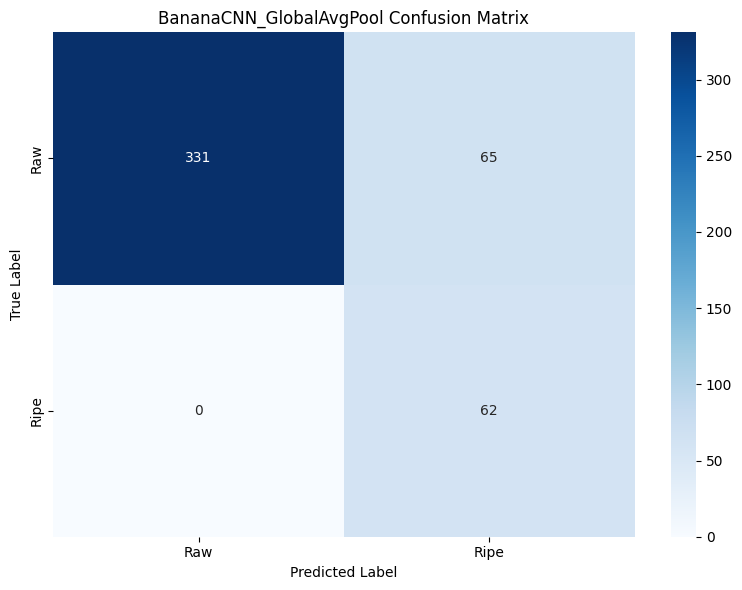

{'accuracy': 0.8580786026200873,
 'precision': 0.4881889763779528,
 'recall': 1.0,
 'f1': 0.656084656084656,
 'confusion_matrix': array([[331,  65],
        [  0,  62]])}

In [43]:
evaluate_model_metrics(model2, test_loader, "BananaCNN_GlobalAvgPool")

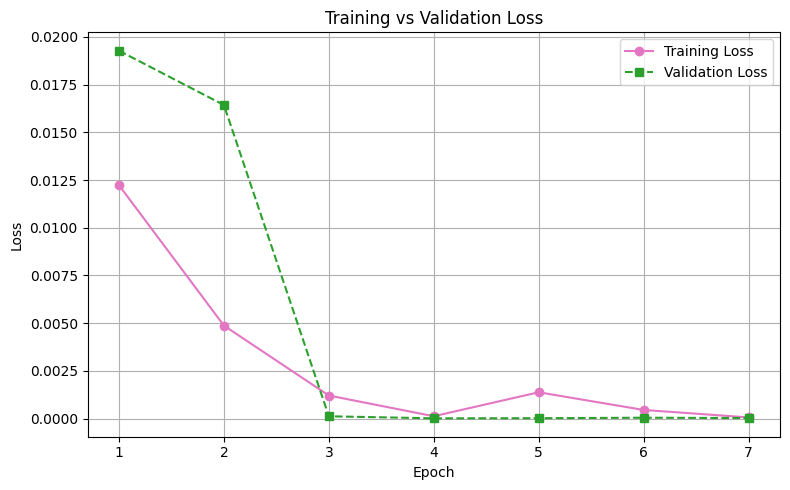

In [44]:
# TODO
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', color='tab:pink', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', color='tab:green', linestyle='--', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PRE-TRAINED RESNET

In [46]:
model3 = get_resnet18_pretrained().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


In [47]:
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001)

In [48]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model3.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model3(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model3, val_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model3.state_dict(), 'best_model3.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break


torch.save(model3.state_dict(), 'ResNet18_Pretrained_model.pth')
print("Model saved!")

Epoch 0 done.
Train accuracy: 0.943089430894309
Train loss: 0.0028659364370289546
Val accuracy: 0.9523809523809523
Val loss: 0.008917301183655149
Epoch 1 done.
Train accuracy: 1.0
Train loss: 5.5982105822887725e-05
Val accuracy: 1.0
Val loss: 5.306373904680922e-06
Epoch 2 done.
Train accuracy: 0.9976771196283392
Train loss: 0.0006033814396994766
Val accuracy: 1.0
Val loss: 4.809009884151497e-06
Epoch 3 done.
Train accuracy: 0.9907084785133565
Train loss: 0.0010052661417007801
Val accuracy: 1.0
Val loss: 1.1819704446852916e-05
Epoch 4 done.
Train accuracy: 0.9976771196283392
Train loss: 0.0002182513184650205
Val accuracy: 1.0
Val loss: 2.282062355550893e-06
Epoch 5 done.
Train accuracy: 1.0
Train loss: 3.3719546203033696e-05
Val accuracy: 1.0
Val loss: 1.010866184341943e-05
Epoch 6 done.
Train accuracy: 1.0
Train loss: 1.3923223931301125e-05
Val accuracy: 1.0
Val loss: 2.111285409357931e-06
Epoch 7 done.
Train accuracy: 1.0
Train loss: 5.367115680858129e-06
Val accuracy: 1.0
Val loss: 1

In [49]:
model3 = get_resnet18_pretrained().to(device)
model3.load_state_dict(torch.load('ResNet18_Pretrained_model.pth'))  # Load your trained model
model3.eval()

# Get one batch from test
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model3(images)
    _, preds = torch.max(outputs, 1)

print("First 10 predictions:", preds[:10].cpu().numpy())
print("First 10 true labels:", labels[:10].cpu().numpy())
print("Matches:", (preds[:10] == labels[:10]).cpu().numpy())

First 10 predictions: [0 0 0 0 1 0 0 0 0 1]
First 10 true labels: [0 0 0 0 1 0 0 0 0 1]
Matches: [ True  True  True  True  True  True  True  True  True  True]


ResNet18_Pretrained Evaluation Metrics
Accuracy:  0.9520
Precision: 0.7381
Recall:    1.0000
F1 Score:  0.8493

Classification Report:
              precision    recall  f1-score   support

         Raw       1.00      0.94      0.97       396
        Ripe       0.74      1.00      0.85        62

    accuracy                           0.95       458
   macro avg       0.87      0.97      0.91       458
weighted avg       0.96      0.95      0.95       458


Confusion Matrix:
[[374  22]
 [  0  62]]

True Negatives:  374
False Positives: 22
False Negatives: 0
True Positives:  62


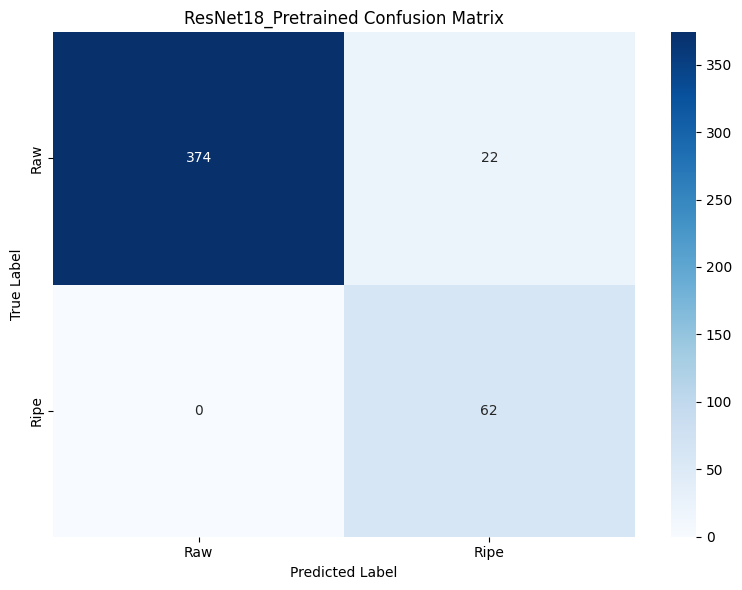

{'accuracy': 0.9519650655021834,
 'precision': 0.7380952380952381,
 'recall': 1.0,
 'f1': 0.8493150684931506,
 'confusion_matrix': array([[374,  22],
        [  0,  62]])}

In [50]:
evaluate_model_metrics(model3, test_loader, "ResNet18_Pretrained")

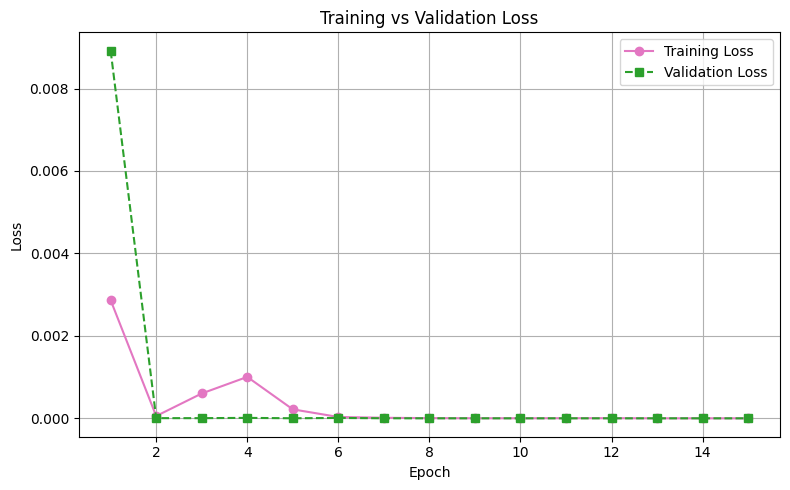

In [51]:
# TODO
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', color='tab:pink', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', color='tab:green', linestyle='--', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# GLOBAL POOLING + REGULARIZATION + DROPOUT

In [52]:
class BCNN_GAP_RD(nn.Module):
    """Uses Global Average Pooling before classification"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Global avg pooling
        self.dropout = nn.Dropout(0.5)  # Add dropout with 50% probability
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.global_pool(x)  # [batch, 256, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 256]
        x = self.dropout(x)  # Apply dropout before FC
        x = self.fc(x)
        return x

In [53]:
model4 = BCNN_GAP_RD().to(device)

In [54]:
optimizer = torch.optim.Adam(model4.parameters(), lr=1e-3, weight_decay=1e-4)  # Add weight_decay

In [55]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model4.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model4(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model4, val_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model4.state_dict(), 'best_model4.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.8130081300813008
Train loss: 0.012617115515449737
Val accuracy: 0.0
Val loss: 0.04048155886786325
Epoch 1 done.
Train accuracy: 0.9616724738675958
Train loss: 0.003355028639946665
Val accuracy: 1.0
Val loss: 0.003561801144054958
Epoch 2 done.
Train accuracy: 0.991869918699187
Train loss: 0.000733535748968089
Val accuracy: 1.0
Val loss: 4.1932848814342704e-05
Epoch 3 done.
Train accuracy: 0.9988385598141696
Train loss: 0.00017084403782347422
Val accuracy: 1.0
Val loss: 2.6183790482935453e-05
Epoch 4 done.
Train accuracy: 1.0
Train loss: 6.553039127329644e-05
Val accuracy: 1.0
Val loss: 8.609895649853916e-06
Epoch 5 done.
Train accuracy: 0.9941927990708479
Train loss: 0.0010414856293889869
Val accuracy: 1.0
Val loss: 2.7409900905608777e-07
Epoch 6 done.
Train accuracy: 0.967479674796748
Train loss: 0.0031085070138786347
Val accuracy: 1.0
Val loss: 0.0024893805384635925
Epoch 7 done.
Train accuracy: 1.0
Train loss: 0.0002820941553457611
Val accuracy: 1.0
Va

BCNN_GAP_RD Evaluation Metrics
Accuracy:  0.9716
Precision: 0.8267
Recall:    1.0000
F1 Score:  0.9051

Classification Report:
              precision    recall  f1-score   support

         Raw       1.00      0.97      0.98       396
        Ripe       0.83      1.00      0.91        62

    accuracy                           0.97       458
   macro avg       0.91      0.98      0.94       458
weighted avg       0.98      0.97      0.97       458


Confusion Matrix:
[[383  13]
 [  0  62]]

True Negatives:  383
False Positives: 13
False Negatives: 0
True Positives:  62


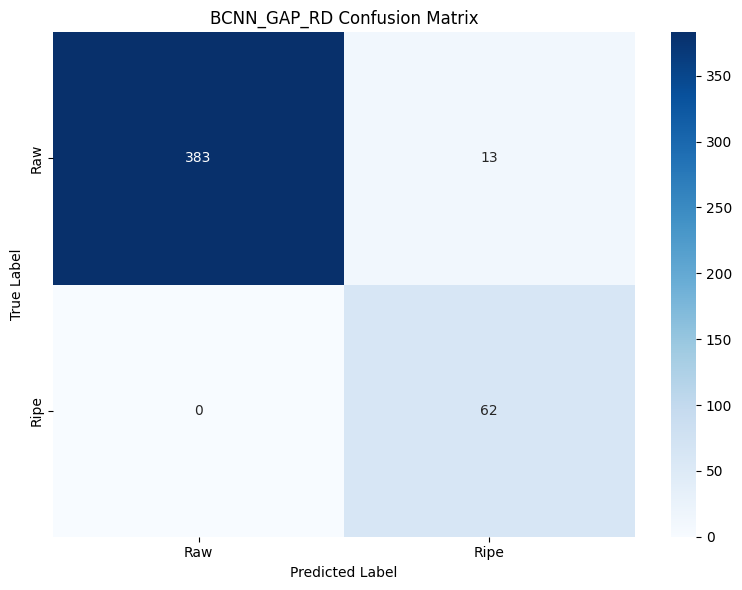

{'accuracy': 0.9716157205240175,
 'precision': 0.8266666666666667,
 'recall': 1.0,
 'f1': 0.9051094890510949,
 'confusion_matrix': array([[383,  13],
        [  0,  62]])}

In [57]:
evaluate_model_metrics(model4, test_loader, "BCNN_GAP_RD")

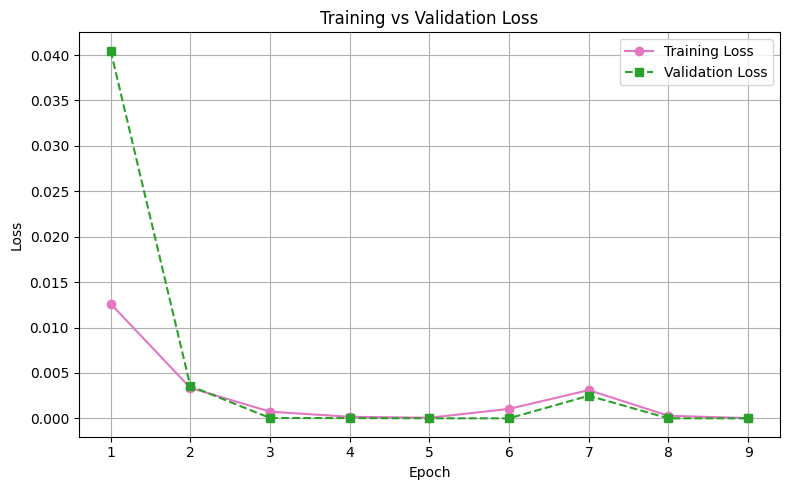

In [58]:
# TODO
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', color='tab:pink', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', color='tab:green', linestyle='--', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PRE-TRAINED RESNET + REGULARIZATION + DROPOUT

In [59]:
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
import torch.optim as optim

def ResNet_GAP_RD():
    """Pretrained ResNet18 with dropout for regularization"""
    weights = ResNet18_Weights.IMAGENET1K_V1
    model5 = models.resnet18(weights=weights)

    # Freeze early layers (optional: speeds up training, focuses on fine-tuning later layers)
    for param in model5.parameters():
        param.requires_grad = False
    for param in model5.layer4.parameters():  # Unfreeze last layer for fine-tuning
        param.requires_grad = True

    # Replace FC with dropout + new FC
    num_features = model5.fc.in_features
    model5.fc = nn.Sequential(
        nn.Dropout(0.5),  # Add dropout (50% probability)
        nn.Linear(num_features, 2)
    )
    return model5

In [62]:
model5 = ResNet_GAP_RD().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=1e-3, weight_decay=1e-4)  # Added weight_decay

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0  # Fixed variable name

for epoch in range(15):
    model5.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model5(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    # Use val_loader, not test_loader
    val_accuracy, val_loss = get_accuracy_and_loss(model5, val_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / len(train_loader)  # Normalize by batches, not total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model5.state_dict(), 'best_model.pth')  # Save best
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# Load best model and evaluate on test
model5.load_state_dict(torch.load('best_model.pth'))
torch.save(model5.state_dict(), 'ResNet_GAP_RD.pth')  # Optional final save
print("model saved!")

# Full test evaluation
test_accuracy, test_loss = get_accuracy_and_loss(model5, test_loader, criterion)
print(f"Test accuracy: {test_accuracy}, Test loss: {test_loss}")


Epoch 0 done.
Train accuracy: 0.9581881533101045
Train loss: 0.11825659807719704
Val accuracy: 1.0
Val loss: 0.0
Epoch 1 done.
Train accuracy: 0.9953542392566783
Train loss: 0.01290261308625944
Val accuracy: 1.0
Val loss: 1.6651269366515668e-07
Epoch 2 done.
Train accuracy: 0.9976771196283392
Train loss: 0.007032584289037105
Val accuracy: 1.0
Val loss: 1.7317932187801316e-05
Epoch 3 done.
Train accuracy: 1.0
Train loss: 0.0006726952486604676
Val accuracy: 1.0
Val loss: 4.5914233418270235e-05
Early stopping triggered.
model saved!
Test accuracy: 0.9956331877729258, Test loss: 0.0002733938795811146


ResNet_GAP_RD Evaluation Metrics
Accuracy:  0.9956
Precision: 0.9688
Recall:    1.0000
F1 Score:  0.9841

Classification Report:
              precision    recall  f1-score   support

         Raw       1.00      0.99      1.00       396
        Ripe       0.97      1.00      0.98        62

    accuracy                           1.00       458
   macro avg       0.98      1.00      0.99       458
weighted avg       1.00      1.00      1.00       458


Confusion Matrix:
[[394   2]
 [  0  62]]

True Negatives:  394
False Positives: 2
False Negatives: 0
True Positives:  62


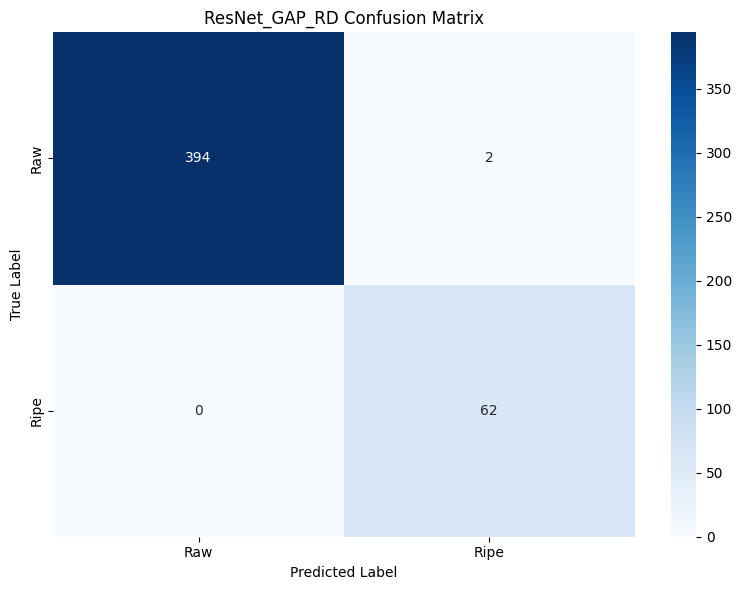

{'accuracy': 0.9956331877729258,
 'precision': 0.96875,
 'recall': 1.0,
 'f1': 0.9841269841269841,
 'confusion_matrix': array([[394,   2],
        [  0,  62]])}

In [64]:
evaluate_model_metrics(model5, test_loader, "ResNet_GAP_RD")

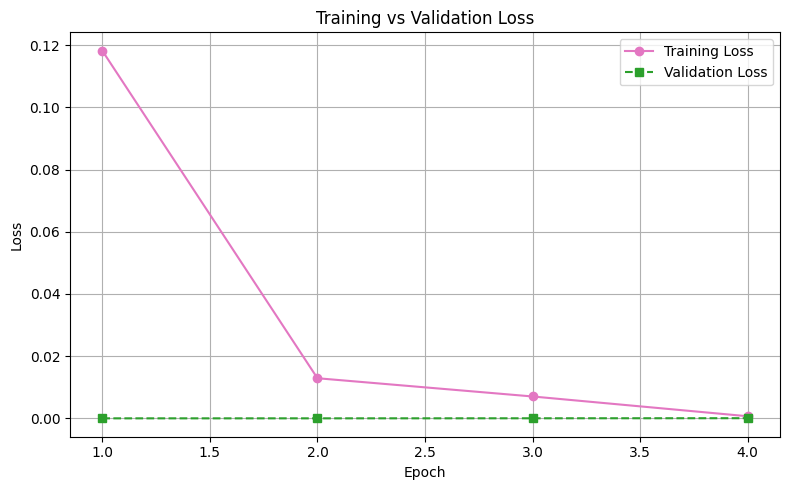

In [65]:
# TODO
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', color='tab:pink', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', color='tab:green', linestyle='--', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()